In [1]:
import json
import os
from collections import defaultdict
import math
import shutil

import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

/home/giosue/miniconda3/envs/ocr/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Precompute all conversation_lengths

In [ ]:
LMSYS = load_dataset("lmsys/lmsys-chat-1m", token="XXX", split="train")

In [19]:
test_message_lengths = dict()
conversation_indices = dict()
for num_turns in [5, 10, 20]:
    conversation_ids = LMSYS["conversation_id"]
    for test_human_message in [True, False]:
        output_setting = "TH" if test_human_message else "TM"
        with open(os.path.join("..", "results", "exp_multi_turn_local", "HO", f"exp_multi_HO_{output_setting}_{num_turns}_turn.json"), "r") as f:
            results = json.load(f)
        if num_turns not in conversation_indices.keys():
            conversation_indices[num_turns] = list()
            for result in results:
                conversation_indices[num_turns].append(conversation_ids.index(result["conversation_id"]))

        print(conversation_indices[num_turns][:5])
        conversations = LMSYS[conversation_indices[num_turns]]["conversation"]

        lengths = [len(conversations[i][-2]["content"]) if test_human_message else len(conversations[i][-1]["content"]) for i in range(len(conversation_indices[num_turns]))]
        # print(lengths[:5], output_setting)
        key = f"{num_turns}_turn_{output_setting}"
        test_message_lengths[key] = lengths
with open("../utils/exp_multi_turn_test_message_lengths.json", "w") as f:
    json.dump(test_message_lengths, f, indent=4)

[9, 121, 164, 223, 239]
[9, 121, 164, 223, 239]
[187, 315, 337, 605, 871]
[187, 315, 337, 605, 871]
[2670, 2892, 5801, 5943, 7011]
[2670, 2892, 5801, 5943, 7011]


In [26]:
# Find most used model for each conversation set
most_used_models = dict()
for num_turns in [5, 10, 20]:
    used_models = LMSYS[conversation_indices[num_turns]]["model"]
    model_counts = defaultdict(int)
    for model in used_models:
        model_counts[model] += 1
    most_used_model = max(model_counts, key=model_counts.get)
    print(max(model_counts.values()) / len(used_models))
    most_used_models[num_turns] = most_used_model
print(most_used_models)

0.6
0.6385542168674698
0.5886889460154242
{5: 'vicuna-13b', 10: 'vicuna-13b', 20: 'vicuna-13b'}


### Function Definitions

In [2]:
def normalize_scores(results, num_turns, test_human_message):
    output_setting = "TH" if test_human_message else "TM"
    key = f"{num_turns}_turn_{output_setting}"
    test_message_lengths = json.load(open("../utils/exp_multi_turn_test_message_lengths.json", "r"))
    lengths = test_message_lengths[key]
    assert len(lengths) == len(results)

    normalized_results = []

    for conversation_result, length in zip(results, lengths):
        if length == 0:
            continue
        
        for key, value in conversation_result.items():
            if key == "conversation_id":
                continue
            conversation_result[key] = value / length
        conversation_result["length"] = length
        normalized_results.append(conversation_result)
    return normalized_results

In [3]:
def read_results(num_turns, human_only, model_only, test_human_message, investigator = False, random_turn = False, native_model = False, mix_inputs = False, empty_assistant = False, normalize = True):
    input_setting = "HO" if human_only else "MO" if model_only else "all"
    output_setting = "TH" if test_human_message else "TM"
    random_turn_setting = "_RT" if random_turn else ""
    investigator_setting = "_INV" if investigator else ""
    native_model_setting = "_NATIVE" if native_model else ""
    mix_inputs_setting  = "_MIX" if mix_inputs else ""
    empty_assistant_setting = "_EA" if empty_assistant else ""
    with open(os.path.join("..", "results", "exp_multi_turn_local", input_setting, f"exp_multi_{input_setting}_{output_setting}{random_turn_setting}{investigator_setting}{native_model_setting}{mix_inputs_setting}{empty_assistant_setting}_{num_turns}_turn.json"), "r") as f:
        results = json.load(f)
    if normalize:
        return normalize_scores(results, num_turns, test_human_message)
    return results

In [4]:
def average_results(multi_turn_results, num_turns, return_nll = True):
    turn_scores = defaultdict(list)
    turn_entropy = defaultdict(list)

    skip_entropy = False if "entropy_turns_1" in multi_turn_results[0].keys() else True

    for entry in multi_turn_results:

        for turn in range(1, num_turns + 1):
            turn_key = f"logprob_turns_{turn}"
            turn_scores[turn_key].append(entry[turn_key])

            if skip_entropy:
                continue
            
            entropy_key = f"entropy_turns_{turn}"
            entropy_value = entry[entropy_key]
            if not math.isnan(entropy_value):
                turn_entropy[entropy_key].append(entry[entropy_key])

    # Calculate average log probabilities per turn
    avg_turn_scores = {turn: np.mean(scores) for turn, scores in turn_scores.items()}

    if skip_entropy:
        avg_entropy = None
    else:
        avg_entropy = {turn: np.mean(entropies) for turn, entropies in turn_entropy.items()}

    if return_nll:
        # Flip sign for NLL
        avg_nll_scores = {turn: -score for turn, score in avg_turn_scores.items()}
        return avg_nll_scores, avg_entropy
    
    return avg_turn_scores, avg_entropy

In [5]:
def bar_chart(scores):
    num_turns = len(scores)
    key = "logprob" if "logprob_turns_1" in scores.keys() else "entropy"
    plt.figure(figsize=(8, 5))
    plt.bar([str(i) for i in range(1, num_turns + 1)], [scores[f"{key}_turns_{i}"] for i in range(1, num_turns + 1)])
    plt.xlabel("Number of Turns")
    plt.ylabel("Average NLL score" if key == "logprob" else "Average Entropy")
    # plt.savefig(os.path.join("..", "plots", f"exp_multi_{num_turns}_turn_nll_scores.png"))
    plt.show()

In [7]:
def update_results():
    cloud_dir = "../results/exp_multi_turn"
    for sub_dirs in os.listdir(cloud_dir):
        for results in os.listdir(os.path.join(cloud_dir, sub_dirs)):
            local_dir = os.path.join("..", "results", "exp_multi_turn_local", sub_dirs)
            if not os.path.exists(local_dir):
                os.makedirs(local_dir)
            shutil.copyfile(os.path.join(cloud_dir, sub_dirs, results), os.path.join(local_dir, results))
update_results()

## 4 Turns

In [2]:
with open(os.path.join("..", "results", "multi_turn_logprobs.json"), "r") as f:
    multi_turn_results = json.load(f)

In [3]:
turn_scores = defaultdict(list)

for entry in multi_turn_results:
    for turn in range(1, 5):
        turn_key = f"logprob_turns_{turn}"
        turn_scores[turn_key].append(entry[turn_key])

# Calculate average log probabilities per turn
avg_turn_scores = {turn: np.mean(scores) for turn, scores in turn_scores.items()}

# Flip sign for NLL
nll_scores = {turn: -score for turn, score in avg_turn_scores.items()}

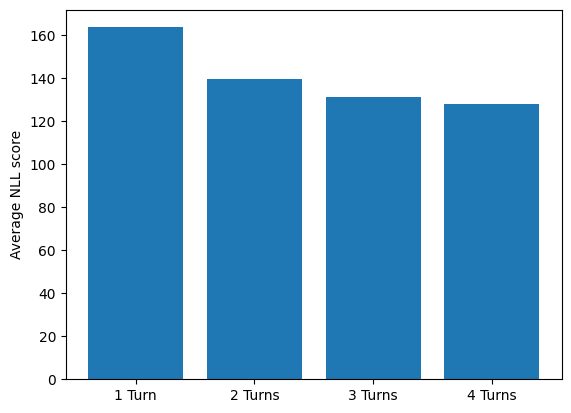

In [4]:
labels = ["1 Turn"] + [f"{i} Turns" for i in range(2, 5)]
plt.bar(labels, [nll_scores[f"logprob_turns_{i}"] for i in range(1, 5)])
plt.ylabel("Average NLL score")
plt.show()

## 5 Turns

### Human only

In [3]:
turns = 5
human_only = True
model_only = False
test_human_message = True
multi_turn_results = read_results(turns, human_only, model_only, test_human_message=True)
avg_nll_scores, avg_entropy = average_results(multi_turn_results, turns, return_nll=True)

NameError: name 'read_results' is not defined

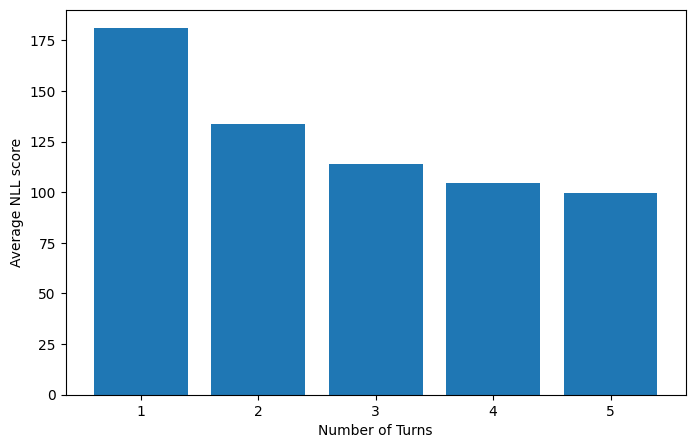

In [36]:
bar_chart(avg_nll_scores, turns, nll=True)

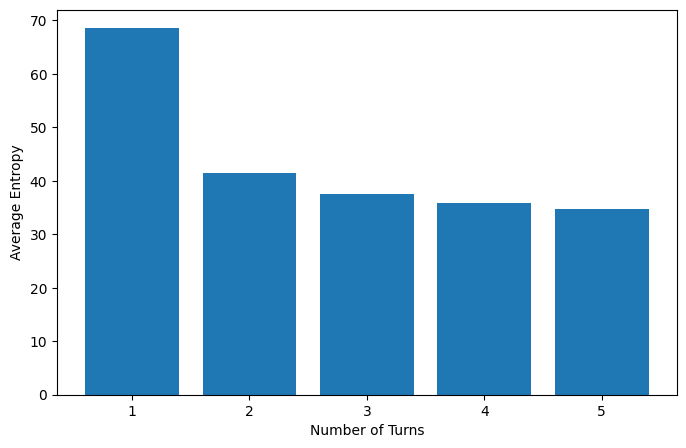

In [37]:
bar_chart(avg_entropy, turns, nll=False)

### Model only

In [7]:
turns = 5
human_only = False
model_only = True
test_human_message = True
multi_turn_results = read_results(turns, human_only, model_only, test_human_message=test_human_message)
avg_nll_scores, avg_entropy = average_results(multi_turn_results, turns, return_nll=True)

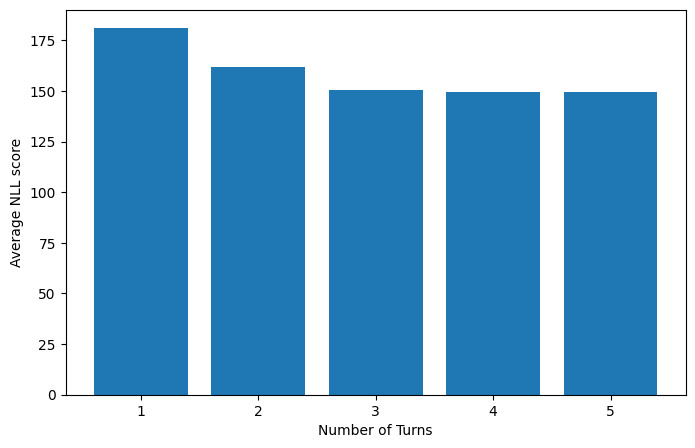

In [8]:
bar_chart(avg_nll_scores)

## 6 Turns

In [ ]:
turns = 6
with open(os.path.join("..", "results", "6_multi_turn_logprobs.json"), "r") as f:
    multi_turn_results = json.load(f)
turn_scores = defaultdict(list)

for entry in multi_turn_results:
    for turn in range(1, 7):
        turn_key = f"logprob_turns_{turn}"
        turn_scores[turn_key].append(entry[turn_key])

# Calculate average log probabilities per turn
avg_turn_scores = {turn: np.mean(scores) for turn, scores in turn_scores.items()}

# Flip sign for NLL
nll_scores = {turn: -score for turn, score in avg_turn_scores.items()}

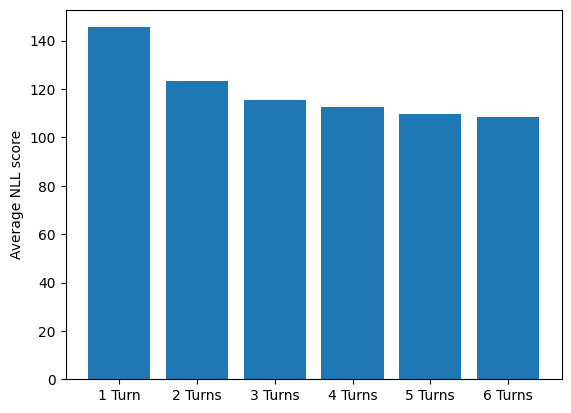

In [9]:
labels = ["1 Turn"] + [f"{i} Turns" for i in range(2, 7)]
plt.bar(labels, [nll_scores[f"logprob_turns_{i}"] for i in range(1, 7)])
plt.ylabel("Average NLL score")
plt.savefig(os.path.join("..", "plots", f"exp_multi_{turns}_turn_nll_scores.png"))
plt.show()

## 10 Turns

### All messages

In [40]:
turns = 10
human_only = False
model_only = False
test_human_message = True
multi_turn_results = read_results(turns, human_only, model_only, test_human_message=True)
avg_nll_scores, avg_entropy = average_results(multi_turn_results, turns, return_nll=True)

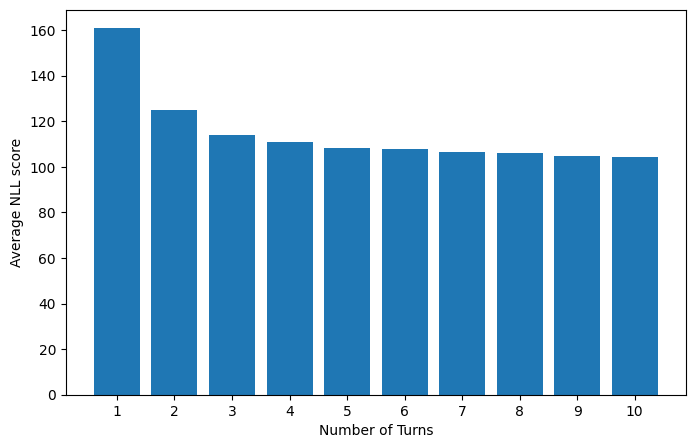

In [42]:
bar_chart(avg_nll_scores, turns)

### Human Only

In [43]:
turns = 10
human_only = True
model_only = False
test_human_message = True
multi_turn_results = read_results(turns, human_only, model_only, test_human_message=True)
avg_nll_scores, avg_entropy = average_results(multi_turn_results, turns, return_nll=True)

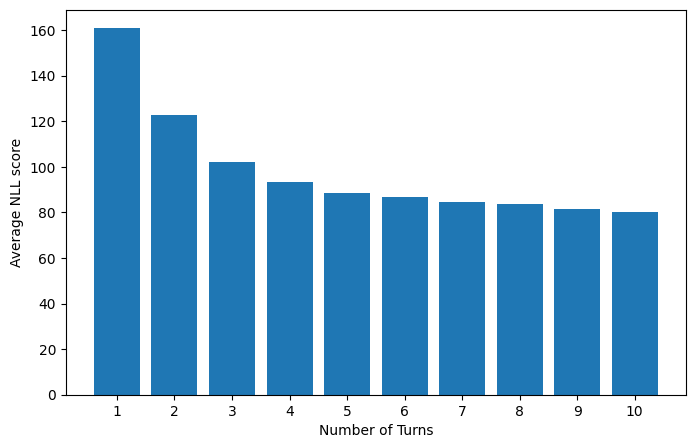

In [44]:
bar_chart(avg_nll_scores, turns)

### Model only

In [5]:
turns = 10
human_only = False
model_only = True
test_human_message = True
multi_turn_results = read_results(turns, human_only, model_only, test_human_message=test_human_message)
avg_nll_scores, avg_entropy = average_results(multi_turn_results, turns, return_nll=True)

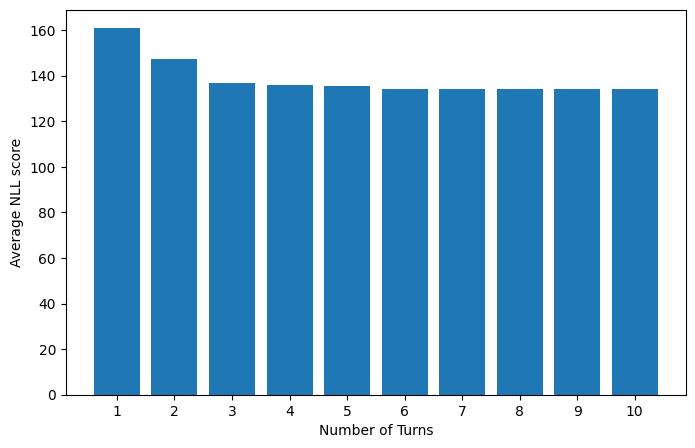

In [6]:
bar_chart(avg_nll_scores)

## 15 Turns

In [46]:
turns = 15
human_only = False
model_only = False
test_human_message = True
multi_turn_results = read_results(turns, human_only, model_only, test_human_message=True)
avg_nll_scores, avg_entropy = average_results(multi_turn_results, turns, return_nll=True)

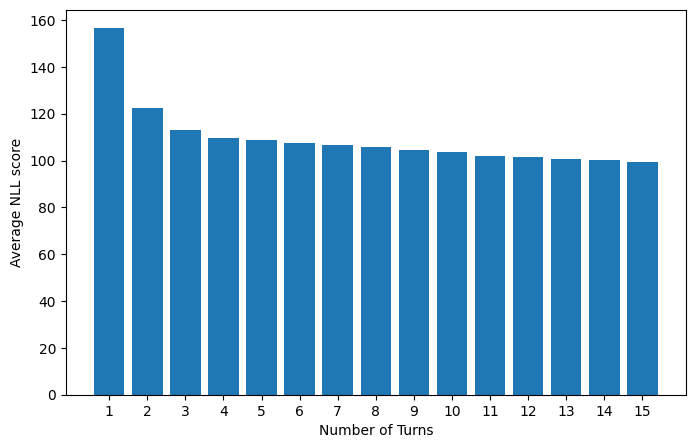

In [47]:
bar_chart(avg_nll_scores, turns)

## 20 Turns

### Human Only

In [48]:
turns = 20
human_only = True
model_only = False
test_human_message = True
multi_turn_results = read_results(turns, human_only, model_only, test_human_message=True)
avg_nll_scores, avg_entropy = average_results(multi_turn_results, turns, return_nll=True)

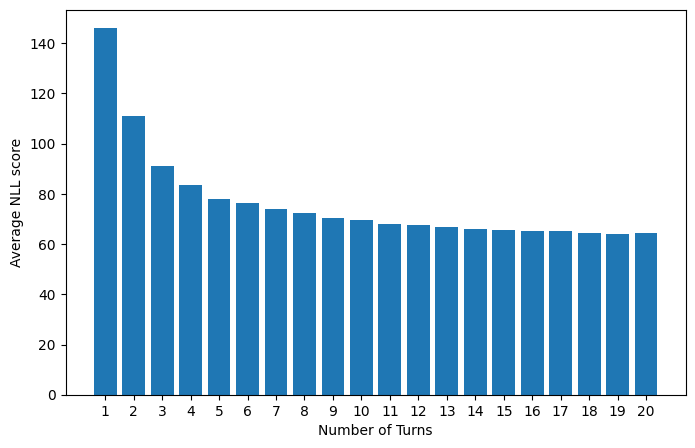

In [49]:
bar_chart(avg_nll_scores, turns)

### Model only

In [65]:
turns = 20
human_only = False
model_only = True
test_human_message = True
multi_turn_results = read_results(turns, human_only, model_only, test_human_message=True)
avg_nll_scores, avg_entropy = average_results(multi_turn_results, turns, return_nll=True)

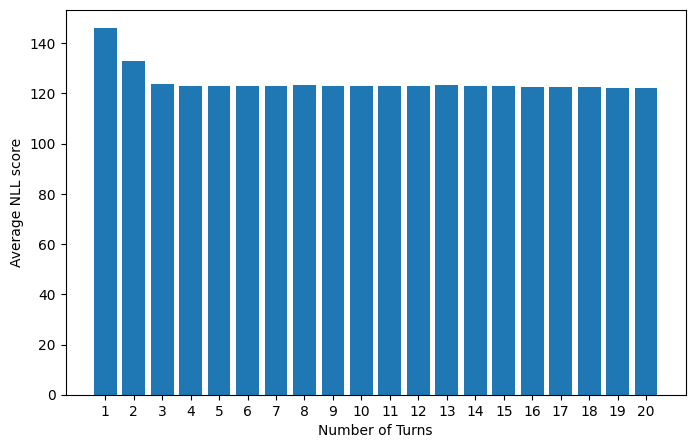

In [66]:
bar_chart(avg_nll_scores)

# Combine multiple experiments in one plot

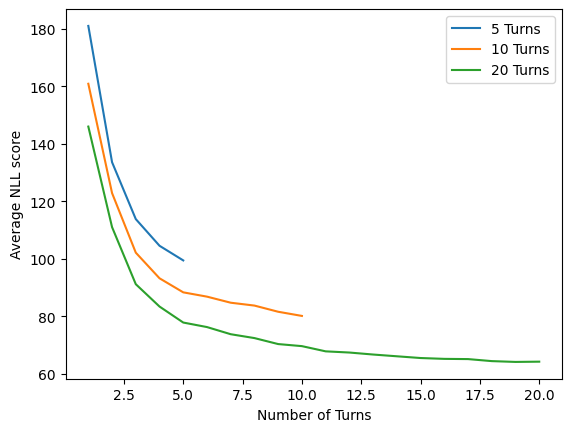

In [ ]:
human_only = True
model_only = False
test_human_message = True

results = dict()
for num_turns in [5, 10, 20]:
    multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=True)
    avg_nll_scores, avg_entropy = average_results(multi_turn_results, num_turns, return_nll=True)
    plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=f"{num_turns} Turns")
plt.xlabel("Number of Turns")
plt.ylabel("Average NLL score")
plt.legend()
plt.show()

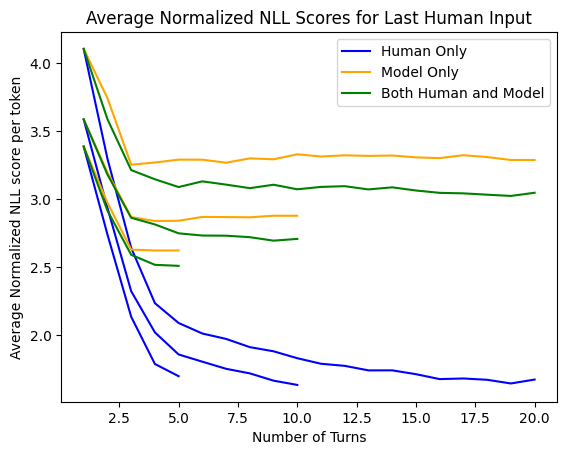

In [10]:
test_human_message = True
normalize = True

results = dict()
for human_only in [True, False, None]:
    if human_only is None:
        model_only = False
        human_only = False
        label = "Both Human and Model"
        color = "green"
    else:
      model_only = not human_only
      label = "Human Only" if human_only else "Model Only"
      color = "blue" if human_only else "orange"
    for num_turns in [5, 10, 20]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, normalize=normalize)
        avg_nll_scores, avg_entropy = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
plt.title("Average Normalized NLL Scores for Last Human Input")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
if normalize:
    plt.ylabel("Average Normalized NLL score per token")
else:
  plt.ylabel("Average NLL score")
normalized_setting = "_norm" if normalize else ""
plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_human{normalized_setting}.png"))
plt.show()

# Score last model answer

## 5 Turns

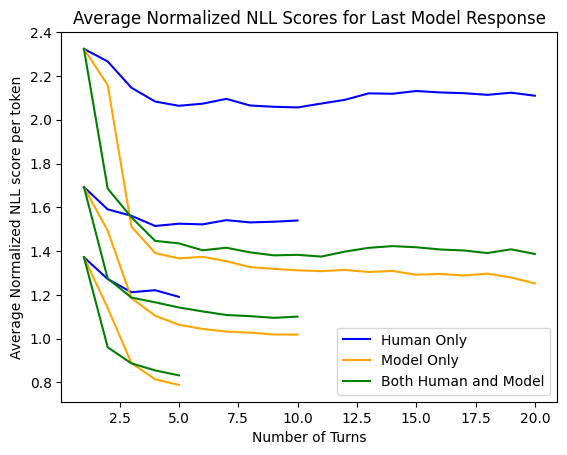

In [14]:
test_human_message = False
normalize = True

results = dict()
for human_only in [True, False, None]:
    if human_only is None:
        model_only = False
        human_only = False
        label = "Both Human and Model"
        color = "green"
    else:
      model_only = not human_only
      label = "Human Only" if human_only else "Model Only"
      color = "blue" if human_only else "orange"
    for num_turns in [5, 10, 20]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, normalize=normalize)
        avg_nll_scores, avg_entropy = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NLL Scores for Last Model Response by Previous Number of Turns")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
plt.title("Average Normalized NLL Scores for Last Model Response")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
if normalize:
    plt.ylabel("Average Normalized NLL score per token")
else:
  plt.ylabel("Average NLL score")
normalized_setting = "_norm" if normalize else ""
plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_model{normalized_setting}.png"))
plt.show()

[121, 2097, 866, 78, 0]
[0, 357, 256, 16, 1969]
[903, 419, 364, 311, 108]


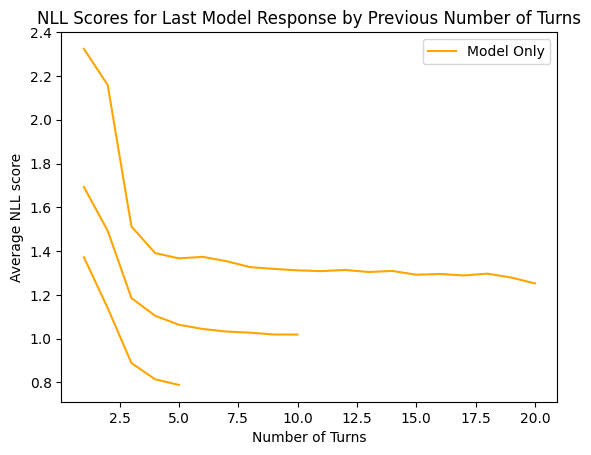

In [129]:
test_human_message = False
normalize = True

results = dict()
model_only = True
human_only = False
label = "Human Only" if human_only else "Model Only"
color = "blue" if human_only else "orange"
for num_turns in [5, 10, 20]:
    multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, normalize=normalize)
    avg_nll_scores, avg_entropy = average_results(multi_turn_results, num_turns, return_nll=True)
    plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NLL Scores for Last Model Response by Previous Number of Turns")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average NLL score")
plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_model.png"))
plt.show()

In [57]:
avg_nll_scores

{'logprob_turns_1': 11.329310519870548,
 'logprob_turns_2': 13.27046095223673,
 'logprob_turns_3': 8.422877373059151,
 'logprob_turns_4': 7.669173008438425,
 'logprob_turns_5': 7.180352844103559,
 'logprob_turns_6': 6.9716307856429305,
 'logprob_turns_7': 6.894434378623096,
 'logprob_turns_8': 6.839999994890412,
 'logprob_turns_9': 6.868232066240967,
 'logprob_turns_10': 6.852068857635158}

Investigate spike at 2 turns

In [201]:
turns = 20
human_only = False
model_only = True
test_human_message = False
inject_random_turn = False

In [210]:
normalize = True
multi_turn_results_norm = read_results(turns, human_only, model_only, test_human_message=test_human_message, random_turn=inject_random_turn, normalize=normalize)
normalize = False
multi_turn_results_no = read_results(turns, human_only, model_only, test_human_message=test_human_message, random_turn=inject_random_turn, normalize=normalize)
# avg_nll_scores, avg_entropy = average_results(multi_turn_results, turns, return_nll=True)

# conversation_ids = set([entry["conversation_id"] for entry in multi_turn_results_norm])
# multi_turn_results_no = [entry for entry in multi_turn_results_no if entry["conversation_id"] in conversation_ids]

In [211]:
avg_nll_scores_no = average_results(multi_turn_results_no, turns, return_nll=True)[0]
avg_nll_scores_norm = average_results(multi_turn_results_norm, turns, return_nll=True)[0]

In [212]:
for key in avg_nll_scores_no.keys():
    print(f"{key}: {avg_nll_scores_norm[key] / avg_nll_scores_no[key]} ")

logprob_turns_1: 0.008204648335115477 
logprob_turns_2: 0.009986810648326969 
logprob_turns_3: 0.008269034989788126 
logprob_turns_4: 0.007887318985079045 
logprob_turns_5: 0.007894528766371478 
logprob_turns_6: 0.008065110636560766 
logprob_turns_7: 0.008007592169619106 
logprob_turns_8: 0.007879440896696632 
logprob_turns_9: 0.0078526053084257 
logprob_turns_10: 0.007839104469103603 
logprob_turns_11: 0.007824627986629343 
logprob_turns_12: 0.007870522601180879 
logprob_turns_13: 0.007824935082714245 
logprob_turns_14: 0.007871945556792893 
logprob_turns_15: 0.0077898946994978645 
logprob_turns_16: 0.007817933346803668 
logprob_turns_17: 0.0077858989568248636 
logprob_turns_18: 0.00784784531649342 
logprob_turns_19: 0.00776130490467289 
logprob_turns_20: 0.007615161132788925 


# Inject Random Turn

### 5 Turns

In [214]:
turns = 5
human_only = True
model_only = False
test_human_message = True
inject_random_turn = True
multi_turn_results = read_results(turns, human_only, model_only, test_human_message=test_human_message, random_turn=inject_random_turn)
avg_nll_scores, avg_entropy = average_results(multi_turn_results, turns, return_nll=True)

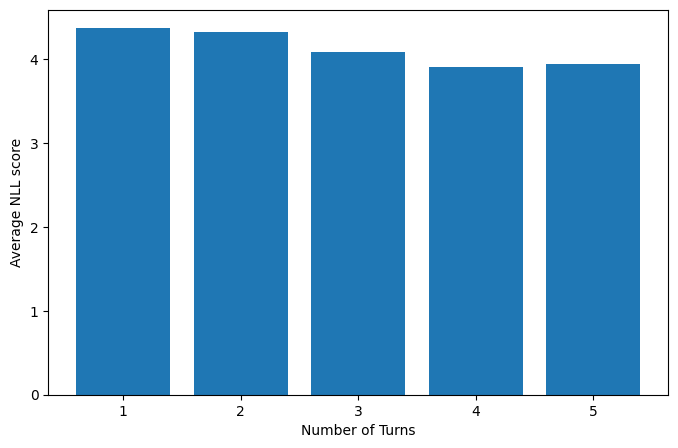

In [215]:
bar_chart(avg_nll_scores)

### 10 Turns

In [8]:
turns = 10
human_only = True
model_only = False
test_human_message = True
inject_random_turn = True
multi_turn_results = read_results(turns, human_only, model_only, test_human_message=test_human_message, random_turn=inject_random_turn)
avg_nll_scores, avg_entropy = average_results(multi_turn_results, turns, return_nll=True)

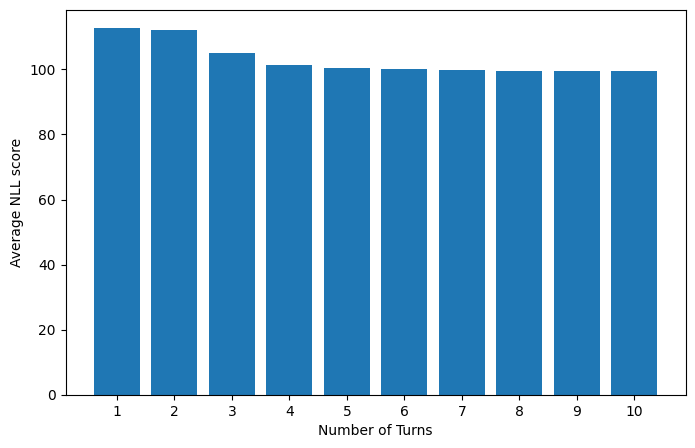

In [9]:
bar_chart(avg_nll_scores)

### Plot comparing to baseline

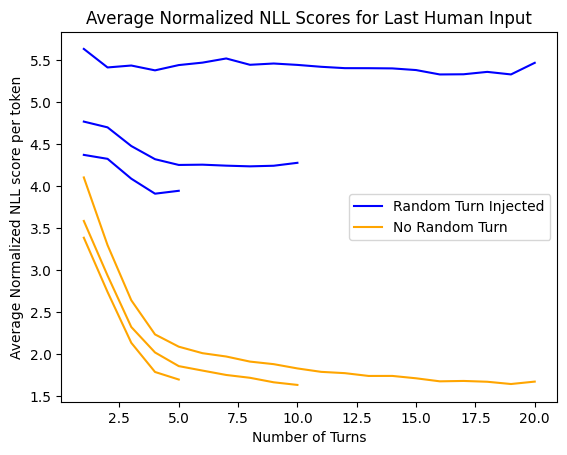

In [10]:
test_human_message = True
human_only = True
model_only = False
results = dict()
for random_turn in [True, False]:
    label = "Random Turn Injected" if random_turn else "No Random Turn"
    color = "blue" if random_turn else "orange"
    for num_turns in [5, 10, 20]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, random_turn=random_turn)
        avg_nll_scores, avg_entropy = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NLL Scores for Last Model Response by Previous Number of Turns")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
plt.title("Average Normalized NLL Scores for Last Human Input")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average Normalized NLL score per token")
plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration__random_turn.png"))
plt.show()

# Investigator setting

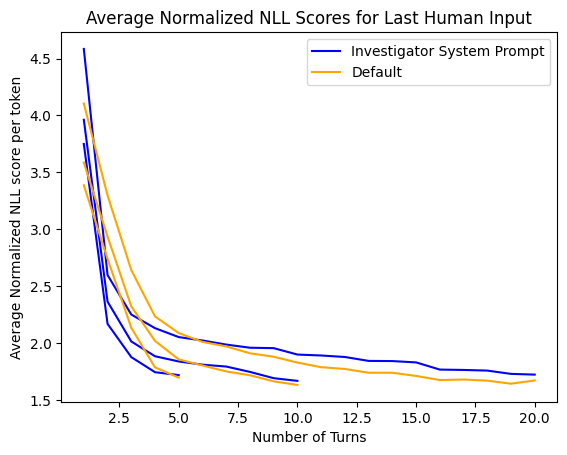

In [25]:
test_human_message = True
human_only = True
model_only = False
results = dict()
for investigator in [True, False]:
    label = "Investigator System Prompt" if investigator else "Default"
    color = "blue" if investigator else "orange"
    for num_turns in [5, 10, 20]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, investigator=investigator)
        avg_nll_scores, avg_entropy = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NLL Scores for Last Model Response by Previous Number of Turns")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
plt.title("Average Normalized NLL Scores for Last Human Input")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average Normalized NLL score per token")

plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_investigator.png"))
plt.show()

# Use Native Model

In [15]:
avg_nll_scores

{'logprob_turns_1': 240.27453482877172,
 'logprob_turns_2': 218.43070241279915,
 'logprob_turns_3': 235.543840172041,
 'logprob_turns_4': 245.31957351103452,
 'logprob_turns_5': 254.47765990599407,
 'logprob_turns_6': 264.14656595939357,
 'logprob_turns_7': 265.72450831714616,
 'logprob_turns_8': 277.6040628269911,
 'logprob_turns_9': 305.5987210424499,
 'logprob_turns_10': 356.583320408675}

In [20]:
logprob_10 = [result["logprob_turns_10"] for result in multi_turn_results]
mean = np.mean(logprob_10)

In [24]:
for result in multi_turn_results:
    if abs(result["logprob_turns_10"] - mean) > 500:
        print(result["logprob_turns_10"])

-3501.980624973774
-4141.176972389221
-3685.2241230756044
-1084.9597802199423
-7000.067098617554
-1620.88954984257
-4769.057696700096
-3975.8195273913443
-1880.52305996418
-2226.8210873133503
-57186.466022372246
-3909.3114453181624
-5089.586242992373
-1793.2334516020492
-1176.2179522514343
-1146.973310041707
-1703.0177915096283
-866.9976890999824
-2071.378961086273
-930.611674785614
-1594.6046329292037
-7697.1979521512985
-3096.5638442486525
-3203.7021490391344


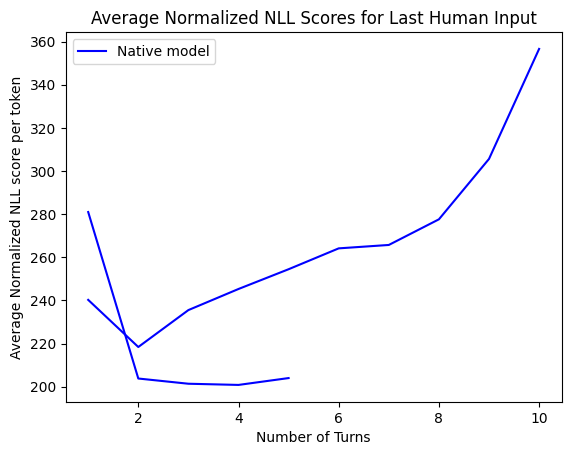

In [14]:
test_human_message = False
human_only = False
model_only = False
results = dict()
for native_model in [True]:
    label = "Native model" if native_model else "Qwen3-8B"
    color = "blue" if native_model else "orange"
    for num_turns in [5, 10]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, native_model=native_model, normalize=False)
        avg_nll_scores, avg_entropy = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NLL Scores for Last Model Response by Previous Number of Turns")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
plt.title("Average Normalized NLL Scores for Last Human Input")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average Normalized NLL score per token")

plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_investigator.png"))
plt.show()

Something goes wrong as number of turns increase. Maybe Chat Template?

# Mix user input

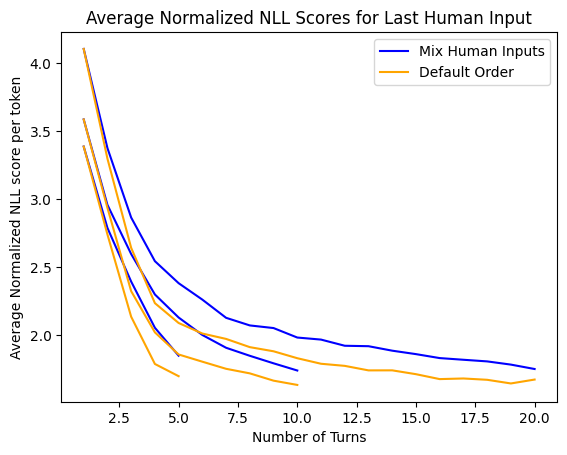

In [26]:
test_human_message = True
human_only = True
model_only = False
results = dict()
for mix_inputs in [True, False]:
    label = "Mix Human Inputs" if mix_inputs else "Default Order"
    color = "blue" if mix_inputs else "orange"
    for num_turns in [5, 10, 20]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, mix_inputs=mix_inputs)
        avg_nll_scores, avg_entropy = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NLL Scores for Last Model Response by Previous Number of Turns")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
plt.title("Average Normalized NLL Scores for Last Human Input")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average Normalized NLL score per token")

plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_mix_inputs.png"))
plt.show()

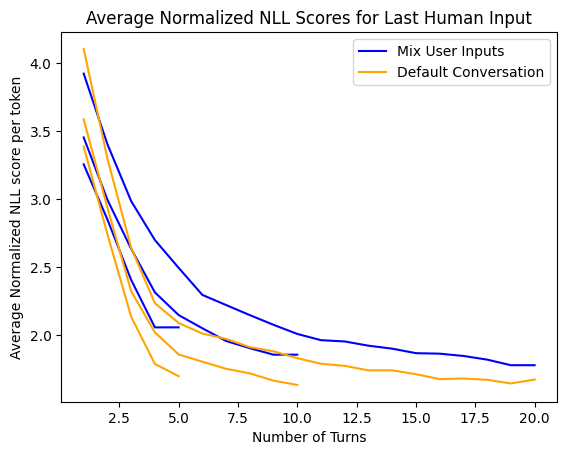

In [13]:
test_human_message = True
human_only = True
model_only = False
results = dict()
for mix_inputs in [True, False]:
    label = "Mix User Inputs" if mix_inputs else "Default Conversation"
    color = "blue" if mix_inputs else "orange"
    for num_turns in [5, 10, 20]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, mix_inputs=mix_inputs)
        avg_nll_scores, avg_entropy = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NLL Scores for Last Model Response by Previous Number of Turns")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
plt.title("Average Normalized NLL Scores for Last Human Input")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average Normalized NLL score per token")

plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_investigator.png"))
plt.show()

# Clear Assistant Message

this is the same as human-only, but with assistant tokens

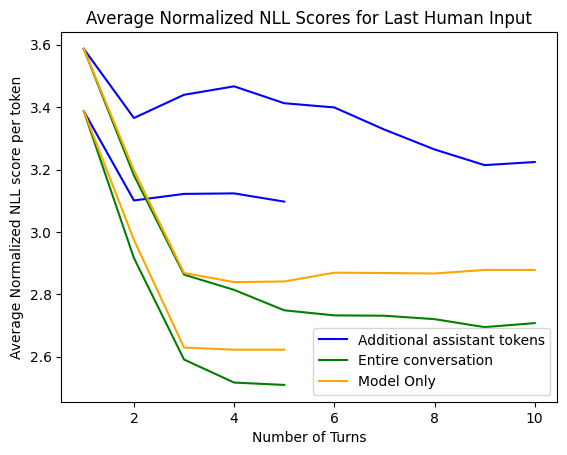

In [32]:
test_human_message = True
human_only = False
model_only = False
results = dict()
for empty_assistant in [True, False, None]:
    if empty_assistant is None:
        model_only = False
        model_only = True
        label = "Model Only"
        color = "orange"
    else:
      label = "Additional assistant tokens" if empty_assistant else "Entire conversation"
      color = "blue" if empty_assistant else "green"
    for num_turns in [5, 10]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, empty_assistant=empty_assistant)
        avg_nll_scores, avg_entropy = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NLL Scores for Last Model Response by Previous Number of Turns")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
plt.title("Average Normalized NLL Scores for Last Human Input")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average Normalized NLL score per token")

plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_empty_assistant.png"))
plt.show()

# TM vs TH in one plot

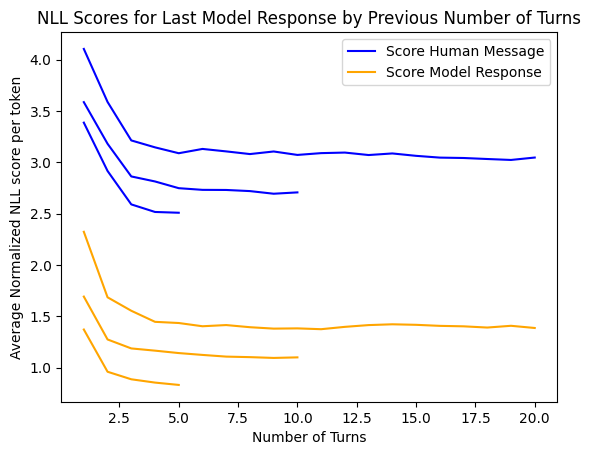

In [29]:
human_only = False
model_only = False
results = dict()
for test_human_message in [True, False]:
    label = "Score Human Message" if test_human_message else "Score Model Response"
    color = "blue" if test_human_message else "orange"
    for num_turns in [5, 10, 20]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message)
        avg_nll_scores, avg_entropy = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NLL Scores for Last Model Response by Previous Number of Turns")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
# plt.title("Average Normalized NLL Scores for Last Human Input")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average Normalized NLL score per token")

plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_TH_vs_TM.png"))
plt.show()